In [1]:
from pathlib import Path
import numpy as np
import yaml

root = Path("../../../Datasets/Zhou2016/original")

npz_files = sorted(root.rglob("*.npz"))
yml_files = sorted(root.rglob("*.yml"))

print("NPZ files:", len(npz_files))
print("YAML files:", len(yml_files))

for f in npz_files[:10]:
    print(f)

NPZ files: 12
YAML files: 12
../../../Datasets/Zhou2016/original/Zhou2016/subject_01_session_01.npz
../../../Datasets/Zhou2016/original/Zhou2016/subject_01_session_02.npz
../../../Datasets/Zhou2016/original/Zhou2016/subject_01_session_03.npz
../../../Datasets/Zhou2016/original/Zhou2016/subject_02_session_01.npz
../../../Datasets/Zhou2016/original/Zhou2016/subject_02_session_02.npz
../../../Datasets/Zhou2016/original/Zhou2016/subject_02_session_03.npz
../../../Datasets/Zhou2016/original/Zhou2016/subject_03_session_01.npz
../../../Datasets/Zhou2016/original/Zhou2016/subject_03_session_02.npz
../../../Datasets/Zhou2016/original/Zhou2016/subject_03_session_03.npz
../../../Datasets/Zhou2016/original/Zhou2016/subject_04_session_01.npz


In [2]:
from pathlib import Path
import numpy as np
import yaml

root = Path("../../../Datasets/Zhou2016/original/Zhou2016")

npz_files = sorted([
    f for f in root.glob("*.npz")
])

yml_files = sorted([
    f for f in root.glob("*.yml")
])

print("Usable NPZ files:", len(npz_files))
print("Usable YAML files:", len(yml_files))

for f in npz_files:
    print(f.name)

Usable NPZ files: 12
Usable YAML files: 12
subject_01_session_01.npz
subject_01_session_02.npz
subject_01_session_03.npz
subject_02_session_01.npz
subject_02_session_02.npz
subject_02_session_03.npz
subject_03_session_01.npz
subject_03_session_02.npz
subject_03_session_03.npz
subject_04_session_01.npz
subject_04_session_02.npz
subject_04_session_03.npz


In [3]:
file_path = npz_files[0]

data = np.load(file_path, allow_pickle=True)

print("File:", file_path.name)
print("Keys:", data.files)

for key in data.files:
    value = data[key]

    print(
        key,
        "| shape:", getattr(value, "shape", None),
        "| dtype:", getattr(value, "dtype", None)
    )

File: subject_01_session_01.npz
Keys: ['data', 'stim']
data | shape: (735510, 14) | dtype: float32
stim | shape: (735510,) | dtype: int16


In [4]:
yml_path = file_path.with_suffix(".yml")

with open(yml_path, "r") as f:
    metadata = yaml.safe_load(f)

metadata

{'acquisition': {'filter': 'Bandpass [0.1-100 Hz], Notch 50 Hz',
  'ground': 'Right mastoid',
  'hardware': 'N/A',
  'reference': 'Left mastoid',
  'samplingrate': 250,
  'sensors': ['Fp1',
   'Fp2',
   'FC3',
   'FCz',
   'FC4',
   'C3',
   'Cz',
   'C4',
   'CP3',
   'CPz',
   'CP4',
   'O1',
   'Oz',
   'O2'],
  'sensortype': 'N/A',
  'software': 'N/A'},
 'documentation': {'description': 'https://neurotechx.github.io/moabb/generated/moabb.datasets.Zhou2016.html#moabb.datasets.Zhou2016',
  'doi': 'https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0162657',
  'investigators': 'Bangyan Zhou, Xiaopei Wu, Zhao Lv, Lei Zhang, Xiaojin Guo',
  'place': 'Key Laboratory of Intelligent Computing & Signal Processing and School of Computer Science and Technology, Anhui University, Hefei, China',
  'repository': 'https://figshare.com/articles/dataset/data_zip/2061654?file=3662952'},
 'formatversion': '0.0.3',
 'id': {'condition': 'None',
  'database': 'Zhou2016',
  'paradigm': 'MI

In [5]:
import pprint

pprint.pp(metadata)

{'acquisition': {'filter': 'Bandpass [0.1-100 Hz], Notch 50 Hz',
                 'ground': 'Right mastoid',
                 'hardware': 'N/A',
                 'reference': 'Left mastoid',
                 'samplingrate': 250,
                 'sensors': ['Fp1',
                             'Fp2',
                             'FC3',
                             'FCz',
                             'FC4',
                             'C3',
                             'Cz',
                             'C4',
                             'CP3',
                             'CPz',
                             'CP4',
                             'O1',
                             'Oz',
                             'O2'],
                 'sensortype': 'N/A',
                 'software': 'N/A'},
 'documentation': {'description': 'https://neurotechx.github.io/moabb/generated/moabb.datasets.Zhou2016.html#moabb.datasets.Zhou2016',
                   'doi': 'https://journals.plos.org/plosone/a

In [6]:
for key in data.files:
    value = data[key]

    print(f"\n--- {key} ---")

    if np.ndim(value) == 0:
        print(value)
    else:
        print("Shape:", value.shape)
        print("First values:")
        print(value.flat[:20])


--- data ---
Shape: (735510, 14)
First values:
[21.520414 52.82854  27.543621 53.83241  35.260857 53.957893 45.675983
 28.861198 36.51569  35.951015 28.610231 50.130646 34.068764 36.8294
 13.426731 46.99356  22.46154  49.56597  30.053291 46.428883]

--- stim ---
Shape: (735510,)
First values:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [7]:
print("ID:")
print(metadata["id"])

print("\nStimulus information:")
print(metadata["stim"])

print("\nUnique stim values:")
values, counts = np.unique(data["stim"], return_counts=True)

for value, count in zip(values, counts):
    print(value, count)

ID:
{'condition': 'None', 'database': 'Zhou2016', 'paradigm': 'MI', 'run': 1, 'session': 1, 'subject': 1, 'timestamp': 2016}

Stimulus information:
{'labels': {'left_hand': 1, 'right_hand': 2, 'feet': 3}, 'nclasses': 3, 'trials_per_class': {'right_hand': 59, 'left_hand': 60, 'feet': 60}, 'offset': 0, 'windowlength': 1250}

Unique stim values:
0 735331
1 60
2 59
3 60


In [8]:
stim = data["stim"]

event_samples = np.where(stim != 0)[0]
event_labels = stim[event_samples]

print("Number of events:", len(event_samples))
print("First event samples:", event_samples[:20])
print("First event labels:", event_labels[:20])

print("\nEvent label counts:")
print(np.unique(event_labels, return_counts=True))

Number of events: 179
First event samples: [  984  3483  5981  8477 10976 13474 15970 18469 20967 23466 25964 28463
 30958 33454 35949 45594 48090 50586 53084 55583]
First event labels: [3 1 1 2 3 2 1 3 1 2 2 3 3 1 2 1 2 1 3 3]

Event label counts:
(array([1, 2, 3], dtype=int16), array([60, 59, 60]))


# Analysis

In [9]:
import mne
import numpy as np
import yaml
from pathlib import Path


root = Path("../../../Datasets/Zhou2016/original/Zhou2016")


# ----------------------------------------
# Load one Weibo subject/session
# ----------------------------------------

def load_weibo_recording(npz_path):
    
    npz_path = Path(npz_path)
    yml_path = npz_path.with_suffix(".yml")

    # Load signal + stimulus
    npz = np.load(npz_path)
    data = npz["data"]          # (samples, channels)
    stim = npz["stim"]          # (samples,)

    # Load metadata
    with open(yml_path, "r") as f:
        metadata = yaml.safe_load(f)

    sfreq = metadata["acquisition"]["samplingrate"]
    ch_names = metadata["acquisition"]["sensors"]

    # MNE expects (channels, samples)
    # Dataset values are in µV -> convert to V
    eeg = data.T * 1e-6

    info = mne.create_info(
        ch_names=ch_names,
        sfreq=sfreq,
        ch_types="eeg"
    )

    raw = mne.io.RawArray(
        eeg,
        info,
        verbose=False
    )

    raw.set_montage(
        "standard_1005",
        on_missing="ignore",
        verbose=False
    )

    # Events are indicated by non-zero stim values
    event_samples = np.where(stim != 0)[0]

    events = np.column_stack([
        event_samples,
        np.zeros(len(event_samples), dtype=int),
        stim[event_samples]
    ]).astype(int)

    return raw, events, metadata

In [10]:
subject_file = root / "subject_01_session_01.npz"

raw, events, metadata = load_weibo_recording(subject_file)

print(raw)

print("\nSampling rate:")
print(raw.info["sfreq"])

print("\nNumber of channels:")
print(len(raw.ch_names))

print("\nDuration:")
print(raw.times[-1], "seconds")

print("\nChannels:")
print(raw.ch_names)

print("\nEvents shape:")
print(events.shape)

print("\nFirst events:")
print(events[:10])

<RawArray | 14 x 735510 (2942.0 s), ~78.6 MiB, data loaded>

Sampling rate:
250.0

Number of channels:
14

Duration:
2942.036 seconds

Channels:
['Fp1', 'Fp2', 'FC3', 'FCz', 'FC4', 'C3', 'Cz', 'C4', 'CP3', 'CPz', 'CP4', 'O1', 'Oz', 'O2']

Events shape:
(179, 3)

First events:
[[  984     0     3]
 [ 3483     0     1]
 [ 5981     0     1]
 [ 8477     0     2]
 [10976     0     3]
 [13474     0     2]
 [15970     0     1]
 [18469     0     3]
 [20967     0     1]
 [23466     0     2]]


In [11]:
label_map = metadata["stim"]["labels"]

print("Original label mapping:")
print(label_map)

print("\nEvent counts:")

event_codes, counts = np.unique(
    events[:, 2],
    return_counts=True
)

for code, count in zip(event_codes, counts):

    label = next(
        name for name, value in label_map.items()
        if value == code
    )

    print(
        f"{code}: {label:<12} -> {count} trials"
    )

Original label mapping:
{'left_hand': 1, 'right_hand': 2, 'feet': 3}

Event counts:
1: left_hand    -> 60 trials
2: right_hand   -> 59 trials
3: feet         -> 60 trials


In [12]:
# ----------------------------------------
# Extract left / right / feet trials
# ----------------------------------------

def extract_weibo_trials(raw, events, metadata):

    sfreq = metadata["acquisition"]["samplingrate"]

    offset = metadata["stim"]["offset"]
    windowlength = metadata["stim"]["windowlength"]

    labels = metadata["stim"]["labels"]

    # Common classes used in our benchmark
    class_map = {
        labels["left_hand"]: 0,
        labels["right_hand"]: 1,
        labels["feet"]: 2
    }

    raw_data = raw.get_data()

    X_all = []
    y_all = []

    for sample, _, code in events:

        if code not in class_map:
            continue

        start = sample + offset
        end = start + windowlength

        trial = raw_data[:, start:end]

        # Make sure trial has expected length
        if trial.shape[1] != windowlength:
            continue

        X_all.append(trial)
        y_all.append(class_map[code])

    X = np.stack(X_all)
    y = np.asarray(y_all)

    return X, y

In [13]:
X, y = extract_weibo_trials(
    raw,
    events,
    metadata
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print(
    "Class distribution:",
    np.unique(y, return_counts=True)
)

X shape: (179, 14, 1250)
y shape: (179,)
Class distribution: (array([0, 1, 2]), array([60, 59, 60]))


In [14]:
sfreq = raw.info["sfreq"]

print("Sampling rate:", sfreq, "Hz")
print("Samples per trial:", X.shape[-1])
print("Trial duration:", X.shape[-1] / sfreq, "seconds")

print(
    "Dataset offset:",
    metadata["stim"]["offset"] / sfreq,
    "seconds"
)

Sampling rate: 250.0 Hz
Samples per trial: 1250
Trial duration: 5.0 seconds
Dataset offset: 0.0 seconds


In [15]:
info = raw.info.copy()

epoch_events = np.zeros(
    (len(y), 3),
    dtype=int
)

epoch_events[:, 0] = np.arange(len(y))
epoch_events[:, 2] = y + 1

event_id = {
    "left_hand": 1,
    "right_hand": 2,
    "feet": 3
}

epochs = mne.EpochsArray(
    X,
    info,
    events=epoch_events,
    event_id=event_id,
    tmin=0.0,
    verbose=False
)

print(epochs)

<EpochsArray | 179 events (all good), 0 – 4.996 s (baseline off), ~23.9 MiB, data loaded,
 'left_hand': 60
 'right_hand': 59
 'feet': 60>


    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


/Users/edsonodake/miniforge3/envs/svm_env/lib/python3.10/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


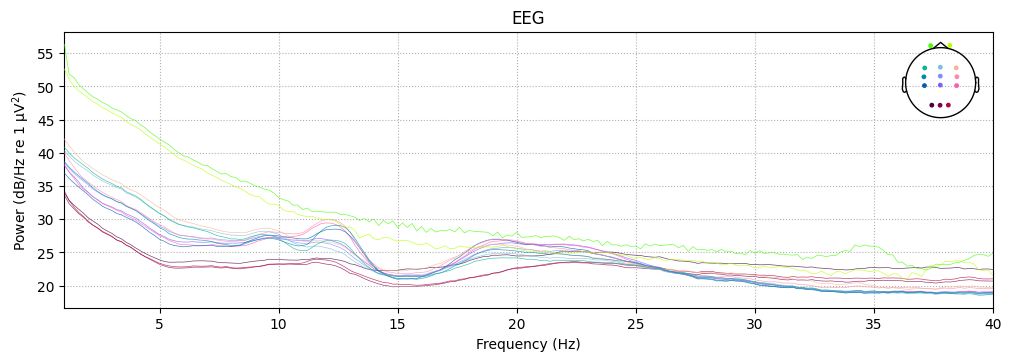

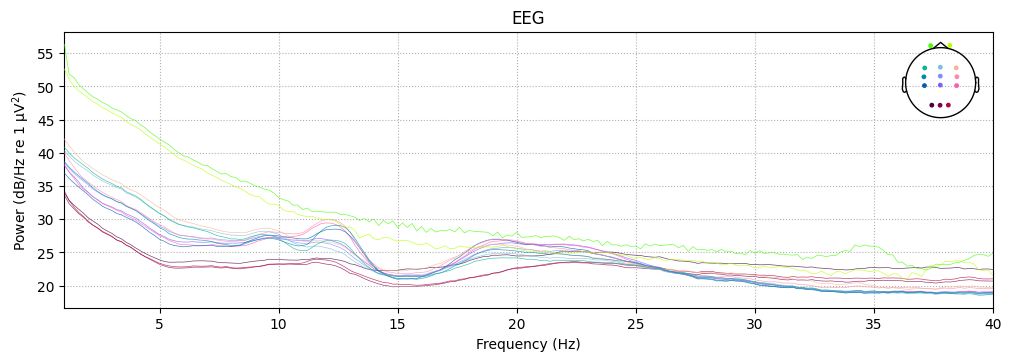

In [16]:
epochs.compute_psd(
    fmin=1,
    fmax=40
).plot()

Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


/Users/edsonodake/miniforge3/envs/svm_env/lib/python3.10/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


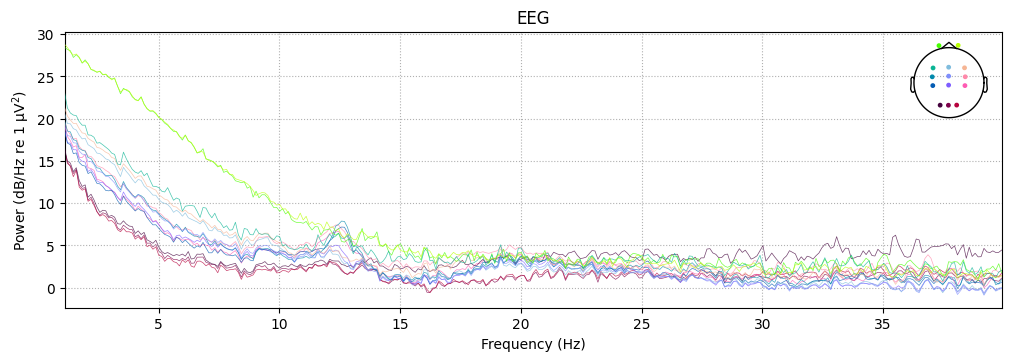

In [17]:
raw.compute_psd(
    fmin=1,
    fmax=40
).plot()

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


/Users/edsonodake/miniforge3/envs/svm_env/lib/python3.10/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


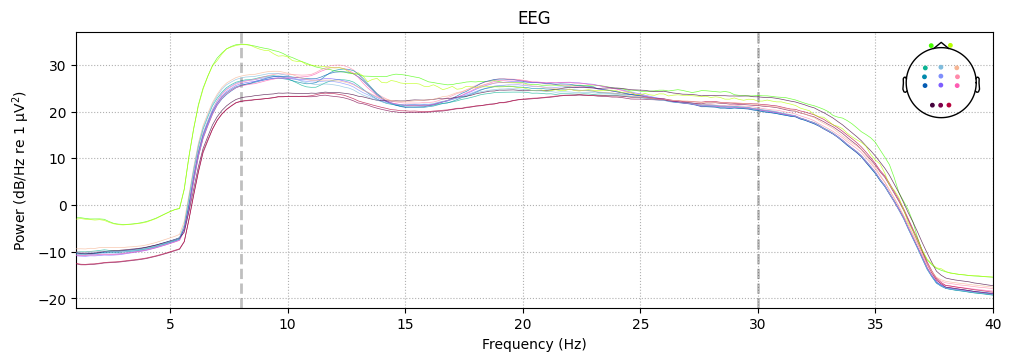

In [18]:
epochs_filtered = epochs.copy()

epochs_filtered.filter(
    8.0,
    30.0,
    fir_design="firwin",
    verbose=False
)

epochs_filtered.compute_psd(
    fmin=1,
    fmax=40
).plot()

In [19]:
print(epochs_filtered.ch_names)

['Fp1', 'Fp2', 'FC3', 'FCz', 'FC4', 'C3', 'Cz', 'C4', 'CP3', 'CPz', 'CP4', 'O1', 'Oz', 'O2']
